# Whole analysis for TES till date. 

- Take data and plot parameters for number of transitions and transition time (use 1000 iterations data)
- Time spent in sync state using SEM
- Nodes which have high median time spent and high degree
- Finding connector hubs
- Finding betweenness centrality
- Finding control nodes
- All the regions get synchronised
- 


In [10]:

%reload_ext autoreload
%autoreload 2

from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path
import glob

### Creating object


In [11]:
analyse =AnalysisFunc()
reader = DataRead()


### Plot of number of transitions and transition times


In [ ]:
# load data 
data_folder = Path("../../data/results/processed/")
files=glob.glob(str(data_folder / "itr*.bz2"))

# Initialize a dictionary to store parameter lists
tranPer_params = {}  # to store number of transitions
trans_params = {}  # to store transition times
sync_params = {}  # to store time spent in sync states

for f in files:
    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[1]  # e.g., "bla"
    df_d = pd.read_pickle(f, compression="bz2")

    # Compute parameters
    params = analyse.compute_param(df_d, 0.05)

    # Store lists in the dictionary
    tranPer_params[f"{name_suffix}"] = params["tran_per"]
    trans_params[f"{name_suffix}"] = params["trans"]
    sync_params[f"{name_suffix}"] = params["sync"]


In [7]:
node_order=np.array(["fn", "bla", "enti", "orbi", "peri", "pir", "re"])

non = np.r_[np.argsort([tranPer_params[k][-1] / 1000 for k in node_order[1:]]) + 1, 0]

non




array([4, 1, 2, 5, 3, 6, 0])

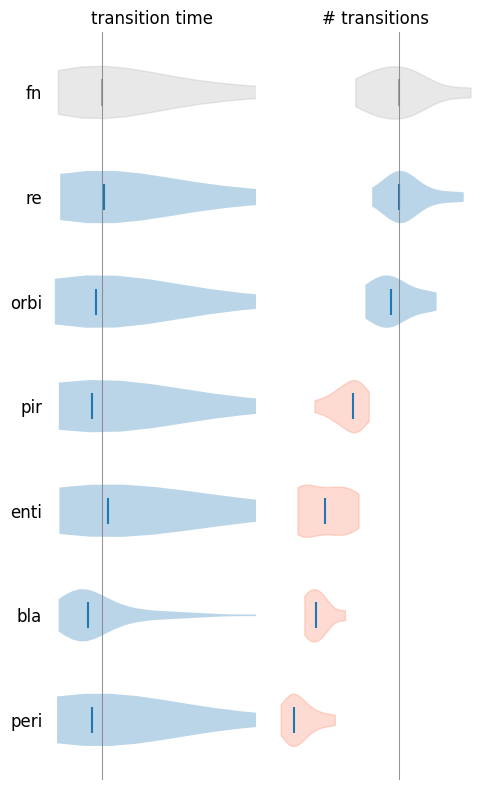

In [9]:
f,(ax1,ax2)= plt.subplots(1,2, figsize=(5,8), sharey=True)

_artists = ax1.violinplot(
    [trans_params[k] for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
ax1.set_yticks(np.arange(1, len(node_order) + 1))
ax1.set_yticklabels(node_order[non], fontsize=12)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax1.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax1.set_xticks([])
ax1.set_xlim(20, 100)
ax1.tick_params(axis="both", which="both", length=0)
ax1.set_title("transition time")
ax1.axvline(np.median(trans_params["fn"]), c=cm.Greys(0.6, 0.8), lw=0.75)


_artists = ax2.violinplot(
    [np.diff(np.array(tranPer_params[k])) for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
# ax3.set_yticks(np.arange(1, len(node_order)+1))
# ax3.set_yticklabels(node_order)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
for i in range(4):
    _artists["bodies"][i].set_color(cm.Reds(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax2.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax2.set_xticks([])
# ax3.set_xlim(80, 500)
ax2.tick_params(axis="both", which="both", length=0)
ax2.set_title("# transitions")
ax2.axvline(np.median(np.diff(tranPer_params["fn"])), c=cm.Greys(0.6, 0.8), lw=0.75)


f.subplots_adjust(wspace=0.8)
f.tight_layout()



## Time spent in sync state


In [13]:
df=reader.data_read_bz2('results/processed/itr_peri.bz2')
plot_data=analyse.compute_time_spent(df,2000)



Number of transitions / 100 iteration [0, 29, 57, 85, 113, 149, 178, 209, 234, 267, 308]
Number of transition [1, 8, 17, 20, 28, 31, 35, 48, 52, 53, 58, 60, 62, 65, 66, 75, 77, 80, 83, 85, 86, 90, 92, 94, 98, 99, 100, 103, 105, 109, 110, 121, 122, 128, 138, 140, 151, 154, 156, 157, 161, 167, 168, 169, 170, 176, 177, 187, 188, 193, 194, 198, 207, 209, 212, 213, 214, 215, 219, 220, 221, 222, 228, 232, 234, 237, 248, 251, 256, 258, 262, 263, 270, 271, 287, 291, 296, 304, 307, 310, 312, 317, 322, 326, 329, 331, 335, 338, 339, 346, 354, 357, 366, 367, 370, 371, 372, 386, 387, 389, 394, 398, 402, 410, 417, 419, 424, 426, 427, 428, 430, 433, 438, 450, 451, 452, 453, 457, 459, 466, 472, 474, 477, 478, 479, 482, 483, 484, 486, 492, 494, 495, 499, 503, 509, 511, 512, 517, 519, 521, 526, 531, 534, 537, 543, 548, 551, 554, 564, 567, 568, 571, 574, 575, 577, 578, 588, 589, 591, 592, 602, 603, 604, 607, 608, 612, 613, 614, 617, 625, 626, 637, 641, 653, 656, 658, 659, 660, 673, 679, 680, 681, 682, 69